In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [99]:
bbwi = pd.read_csv('bbwi.csv')
bbwi["ticker"] = "BBWI"
cb = pd.read_csv("cb.csv")
cb["ticker"] = "CB"
mlm = pd.read_csv("mlm.csv")
mlm["ticker"] = "MLM"
pnr = pd.read_csv("pnr.csv")
pnr["ticker"] = "PNR"
vno = pd.read_csv("vno.csv")
vno["ticker"] = "VNO"

df = pd.concat([bbwi, cb,mlm,pnr,vno], join = "inner")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker
Date,,,,,,,,
2021-01-04,28.139,30.040,27.955,29.286,8329958,0.0,0.0,BBWI
2021-01-05,29.278,30.121,29.071,29.899,5756751,0.0,0.0,BBWI
2021-01-06,30.136,32.436,30.136,32.207,6384528,0.0,0.0,BBWI
2021-01-07,32.517,34.965,32.495,34.144,7030490,0.0,0.0,BBWI
2021-01-08,34.144,35.328,33.730,34.573,3867604,0.0,0.0,BBWI
...,...,...,...,...,...,...,...,...
2024-12-23,41.030,42.080,40.900,42.050,874100,0.0,0.0,VNO
2024-12-24,42.030,42.470,41.630,42.420,498900,0.0,0.0,VNO
2024-12-26,42.160,43.000,42.150,42.650,635600,0.0,0.0,VNO


In [100]:
(df["High"]== df["Low"]).any()
#No volatility

np.False_

In [101]:
max = df.groupby("ticker")["High"].agg("max")
low = df.groupby("ticker")["Low"].agg("min")

for ticker, value in max.items():
    print(f"Maximum for {ticker} is {value}")
for ticker, value in low.items():
    print(f"Minimum for {ticker} is {value}")


Maximum for BBWI is 75.522
Maximum for CB is 299.096
Maximum for MLM is 629.602
Maximum for PNR is 109.597
Maximum for VNO is 45.857
Minimum for BBWI is 23.922
Minimum for CB is 134.183
Minimum for MLM is 266.545
Minimum for PNR is 37.102
Minimum for VNO is 11.982


In [102]:
df["log_returns"] =  np.log(df.groupby("ticker")["Close"].pct_change() +1)
summary = df.groupby("ticker")["log_returns"].agg(["min","max","mean","std","skew"])
summary

,min,max,mean,std,skew
ticker,,,,,
BBWI,-0.137157,0.224626,0.000263,0.029815,0.470074
CB,-0.063751,0.051680,0.000671,0.013328,-0.108173
MLM,-0.058433,0.075276,0.000651,0.017235,0.088879
PNR,-0.073774,0.105373,0.000720,0.017579,0.281915
VNO,-0.095276,0.144422,0.000284,0.026702,0.519010


In [103]:
df_copy = df.reset_index()
first_min_idx = df_copy.groupby("ticker")["log_returns"].idxmin()
second_min_idx = df_copy["log_returns"].mask(df_copy.index.isin(first_min_idx)).groupby(df_copy['ticker']).idxmin()
df_copy.iloc[second_min_idx]


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,log_returns
16,2021-01-27,29.581,30.321,26.697,27.762,20886374,0.0,0.0,BBWI,-0.135798
1056,2021-03-19,156.702,157.526,148.942,149.045,6915700,0.0,0.0,CB,-0.054390
2336,2022-04-22,364.778,364.778,346.202,347.093,497200,0.0,0.0,MLM,-0.054752
3438,2022-09-13,44.321,44.321,43.094,43.142,1258800,0.0,0.0,PNR,-0.055104
4699,2023-09-21,24.080,24.080,22.260,22.328,7810700,0.0,0.0,VNO,-0.093974


In [104]:
first_max_idx = df_copy.groupby("ticker")["log_returns"].idxmax()
second_max_idx = df_copy["log_returns"].mask(df_copy.index.isin(first_max_idx)).groupby(df_copy['ticker']).idxmax()
df_copy.iloc[second_max_idx]


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,log_returns
980,2024-11-25,35.820,36.821,34.143,35.095,29582200,0.0,0.0,BBWI,0.152803
1026,2021-02-04,146.455,151.795,145.887,151.636,3183200,0.0,0.0,CB,0.046599
2010,2021-01-06,291.157,298.339,288.275,293.739,2489100,0.0,0.0,MLM,0.074719
3594,2023-04-27,52.917,55.921,52.373,55.921,3430200,0.0,0.0,PNR,0.093017
4749,2023-12-01,22.971,26.173,22.630,26.046,5513700,0.0,0.0,VNO,0.128203


In [105]:
weekly_median = (df_copy.groupby("ticker")
    .resample("W-MON", on="Date")["Volume"]
    .sum()
    .groupby("ticker")
    .median())
weekly_median

ticker
BBWI    17713100.0
CB       8162800.0
MLM      1903900.0
PNR      6107600.0
VNO      9355300.0
Name: Volume, dtype: float64

In [106]:
tot_log_ret = df.groupby("ticker")["log_returns"].agg("sum")
tot_log_ret.idxmin(), tot_log_ret.min()

('BBWI', 0.2640229094831357)

In [107]:
df["volume_class"] = pd.qcut(df["Volume"], 3, labels=False)
df["volume_class"] = df["volume_class"].apply(lambda x: "Low" if (x == 0) else
                      "Medium" if (x== 1) else
                      "High")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,log_returns,volume_class
Date,,,,,,,,,,
2021-01-04,28.139,30.040,27.955,29.286,8329958,0.0,0.0,BBWI,NaN,High
2021-01-05,29.278,30.121,29.071,29.899,5756751,0.0,0.0,BBWI,0.020715,High
2021-01-06,30.136,32.436,30.136,32.207,6384528,0.0,0.0,BBWI,0.074359,High
2021-01-07,32.517,34.965,32.495,34.144,7030490,0.0,0.0,BBWI,0.058403,High
2021-01-08,34.144,35.328,33.730,34.573,3867604,0.0,0.0,BBWI,0.012486,High
...,...,...,...,...,...,...,...,...,...,...
2024-12-23,41.030,42.080,40.900,42.050,874100,0.0,0.0,VNO,0.012925,Low
2024-12-24,42.030,42.470,41.630,42.420,498900,0.0,0.0,VNO,0.008761,Low
2024-12-26,42.160,43.000,42.150,42.650,635600,0.0,0.0,VNO,0.005407,Low


In [108]:
plot_data = df.pivot(columns = "ticker" ,values = "log_returns")


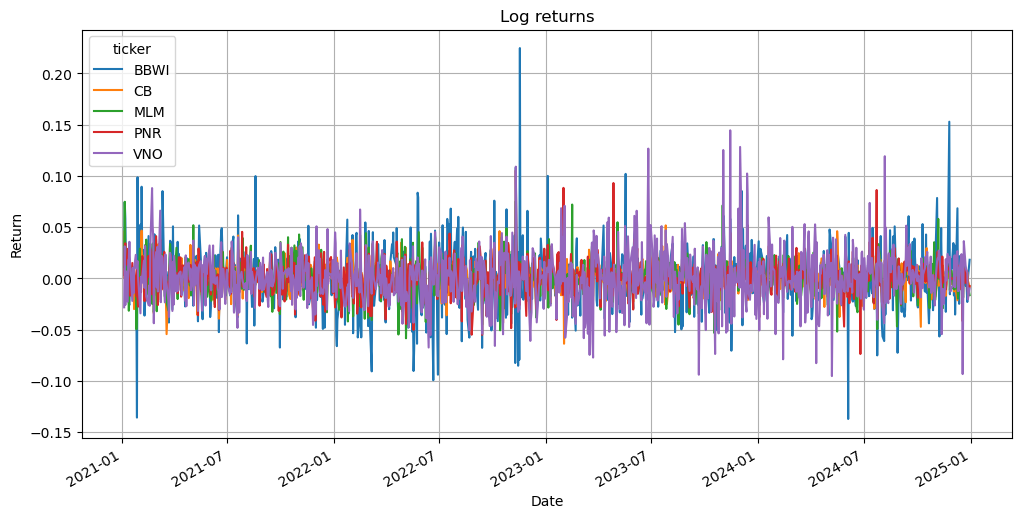

In [109]:
plot_data.plot(figsize=(12,6))
plt.title("Log returns")
plt.ylabel("Return")
plt.xlabel("Date")
plt.grid(True)
plt.show()

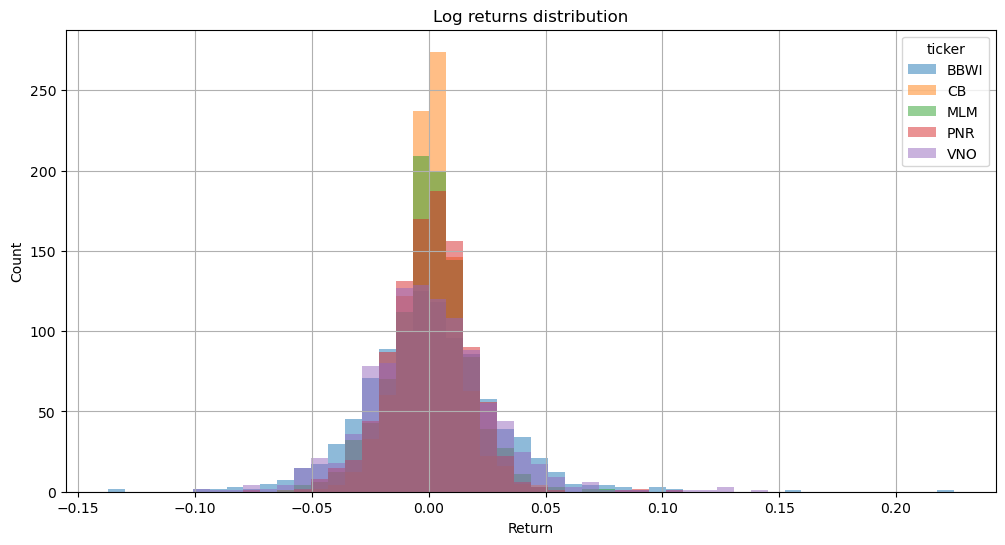

In [110]:
plot_data.plot.hist(figsize=(12,6), alpha=0.5, bins=50)
plt.title("Log returns distribution")
plt.xlabel("Return")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [111]:
p2 =  pd.read_csv('companies_no_subindustry.csv')
p2

,Symbol,Security,GICS_Sector,hq,included,Founded
0,MMM,3M,Industrials,"Saint Paul, Minnesota",09.08.1976,1902
1,AOS,A. O. Smith,Industrials,"Milwaukee, Wisconsin",26.07.2017,1916
2,ABT,Abbott,Health Care,"North Chicago, Illinois",31.03.1964,1888
3,ABBV,AbbVie,Health Care,"North Chicago, Illinois",31.12.2012,2013 (1888)
4,ABMD,Abiomed,Health Care,"Danvers, Massachusetts",31.05.2018,1981
...,...,...,...,...,...,...
498,YUM,Yum! Brands,Consumer Discretionary,"Louisville, Kentucky",06.10.1997,1997
499,ZBRA,Zebra Technologies,Information Technology,"Lincolnshire, Illinois",23.12.2019,1969
500,ZBH,Zimmer Biomet,Health Care,"Warsaw, Indiana",07.08.2001,1927
501,ZION,Zions Bancorporation,Financials,"Salt Lake City, Utah",22.06.2001,1873


In [112]:
missing = p2["included"].isna().sum()
print(missing, "have missing inclusion dates")

45 have missing inclusion dates


In [113]:
p2c = p2[p2["included"].notna()].copy()
p2c

,Symbol,Security,GICS_Sector,hq,included,Founded
0,MMM,3M,Industrials,"Saint Paul, Minnesota",09.08.1976,1902
1,AOS,A. O. Smith,Industrials,"Milwaukee, Wisconsin",26.07.2017,1916
2,ABT,Abbott,Health Care,"North Chicago, Illinois",31.03.1964,1888
3,ABBV,AbbVie,Health Care,"North Chicago, Illinois",31.12.2012,2013 (1888)
4,ABMD,Abiomed,Health Care,"Danvers, Massachusetts",31.05.2018,1981
...,...,...,...,...,...,...
498,YUM,Yum! Brands,Consumer Discretionary,"Louisville, Kentucky",06.10.1997,1997
499,ZBRA,Zebra Technologies,Information Technology,"Lincolnshire, Illinois",23.12.2019,1969
500,ZBH,Zimmer Biomet,Health Care,"Warsaw, Indiana",07.08.2001,1927
501,ZION,Zions Bancorporation,Financials,"Salt Lake City, Utah",22.06.2001,1873


In [114]:
p2c["included"] = pd.to_datetime(p2c["included"], dayfirst=True, errors="coerce")
young = p2c["included"].idxmax()
p2c.iloc[young]


Symbol                            ANET
Security               Arista Networks
GICS_Sector     Information Technology
hq             Santa Clara, California
included           2018-08-28 00:00:00
Founded                           2004
Name: 49, dtype: object

In [115]:
old = p2c["included"].idxmin()
p2c.iloc[old]


Symbol                          MO
Security                    Altria
GICS_Sector       Consumer Staples
hq              Richmond, Virginia
included       1957-03-04 00:00:00
Founded                       1985
Name: 25, dtype: object

In [116]:
p2c['Founded'] = p2c['Founded'].str[0:4]
p2c['Founded'] = pd.to_datetime(p2c["Founded"], errors="coerce")
median = p2c["Founded"].median()
from datetime import datetime, date
today = date.today()
median = datetime.date(median)

age = today.year - median.year - ((today.month, today.day) < (median.month, median.day))
age

54

<Axes: ylabel='Security'>

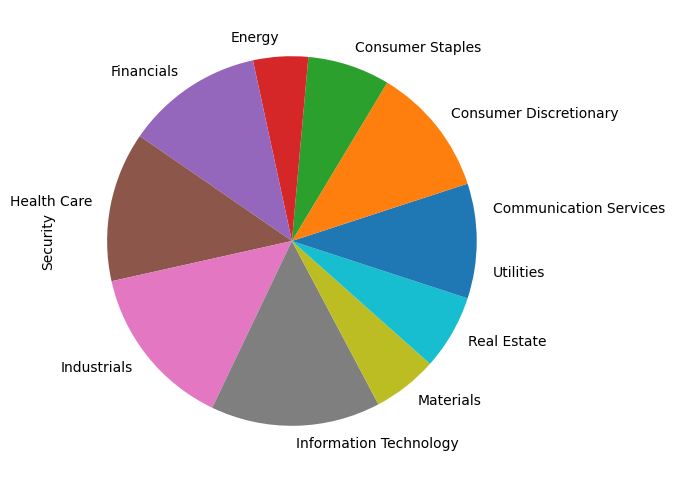

In [117]:
count = p2c.groupby("GICS_Sector")["Security"].count()
count.plot.pie(figsize=(12,6))


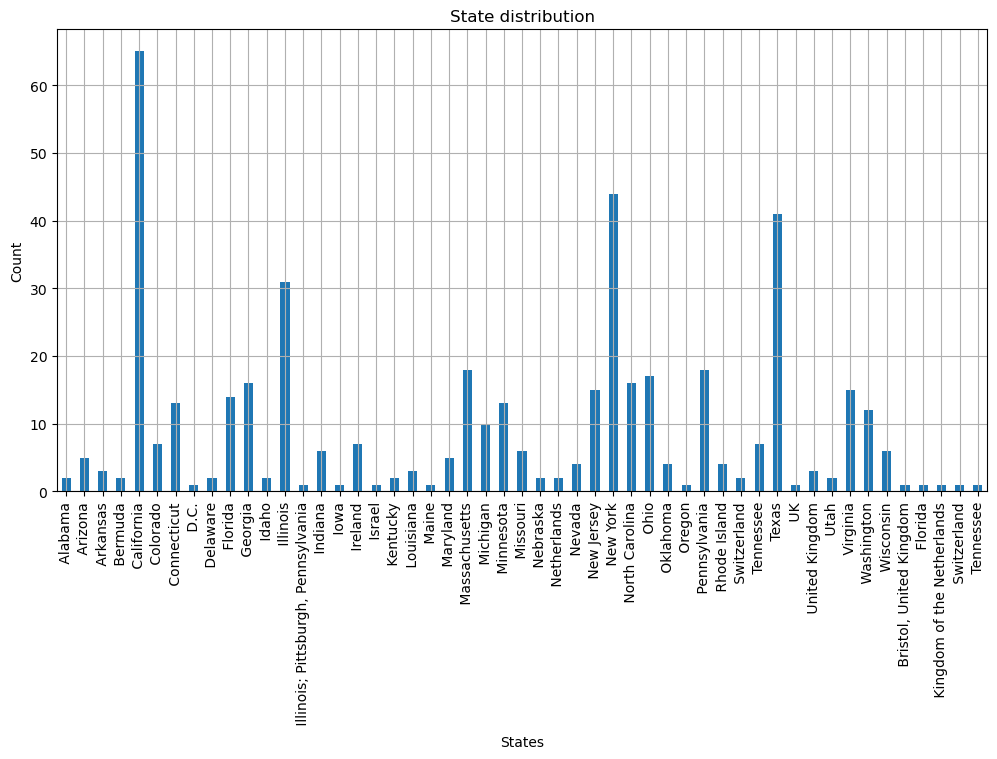

In [118]:
p2c[["City", "State"]] = p2c['hq'].str.split(",", n=1, expand = True)
state_count = p2c.groupby("State")["Security"].count()
state_count.plot.bar(figsize=(12,6))
plt.title("State distribution")
plt.xlabel("States")
plt.ylabel("Count")
plt.grid(True)
plt.show()

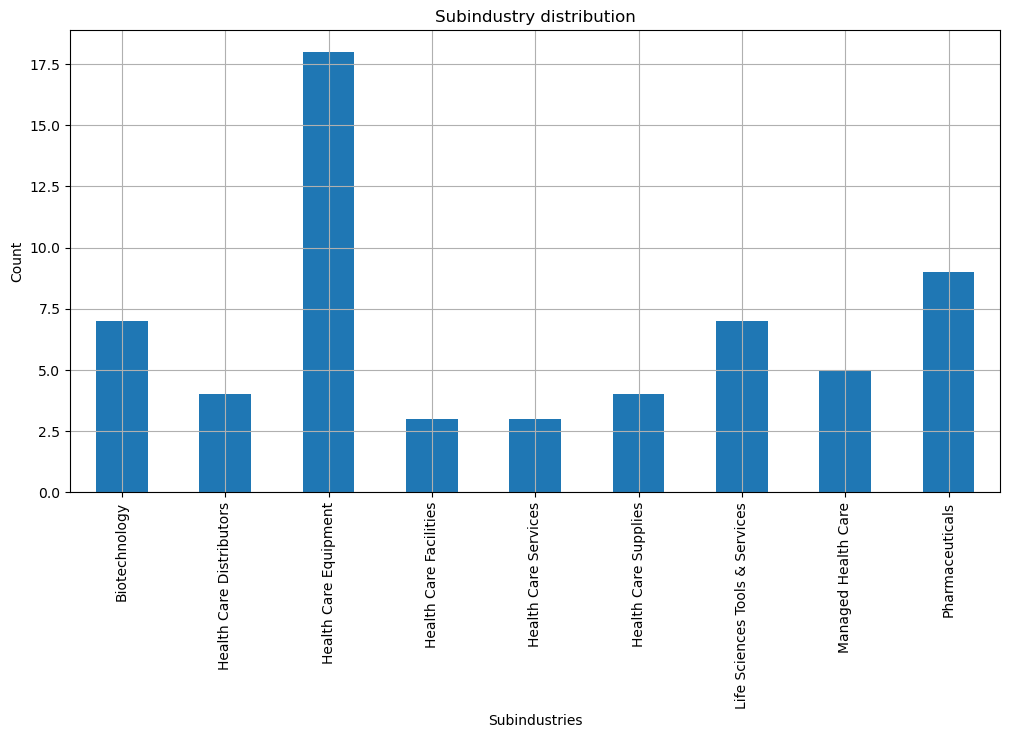

In [119]:
p27 =  pd.read_csv('companies_subindustry.csv')
new = p2c.merge(p27, how="inner", on="Symbol")
n_gics = new[new["GICS_Sector"]=="Health Care"].groupby("subindustry")["Security"].count()
n_gics.plot.bar(figsize=(12,6))
plt.title("Subindustry distribution")
plt.xlabel("Subindustries")
plt.ylabel("Count")
plt.grid(True)
plt.show()

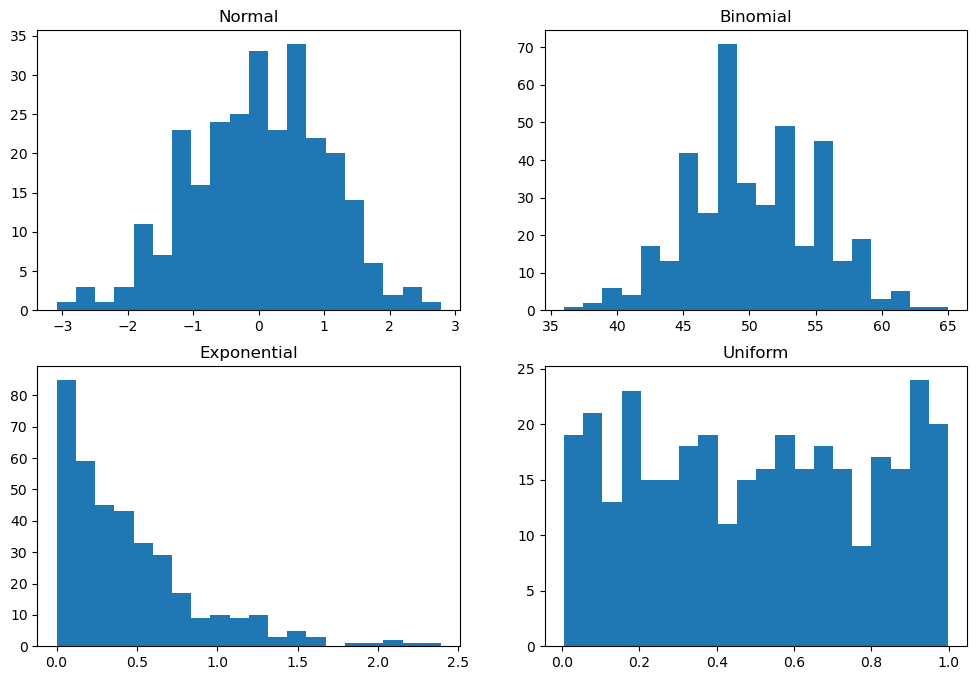

In [120]:
n_obs = np.random.randint(100,501)
u_obs = np.random.randint(100,501)
exp_obs = np.random.randint(100,501)
bin_obs = np.random.randint(100,501)
v1 = np.random.normal(0,1, n_obs)
v2 = np.random.binomial(100,0.5,bin_obs)
v3 = np.random.exponential(0.5, exp_obs)
v4 = np.random.uniform(0,1, u_obs)

fig, ax = plt.subplots(2, 2, figsize=(12,8))

ax[0,0].hist(v1, bins = 20); ax[0,0].set_title("Normal")
ax[0,1].hist(v2, bins = 20); ax[0,1].set_title("Binomial")
ax[1,0].hist(v3, bins = 20); ax[1,0].set_title("Exponential")
ax[1,1].hist(v4, bins = 20); ax[1,1].set_title("Uniform")

plt.show()